# Facial Emotion Detector

Check GPU is active

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus)
assert len(gpus) > 0, 'No GPU found'

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Mount Google Drive

In [25]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/facial-emotion'
DATA_DIR = '/content/data'
CACHE_DIR = DRIVE_DIR

import os
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, 'images')):
    print('Unzipping images to local disk...')
    !unzip -q "{DRIVE_DIR}/images.zip" -d "{DATA_DIR}/"
    print('Done.')
else:
    print('Local images already present, skipping.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local images already present, skipping.


In [26]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

def create_data(direc):
    img_path = []
    label = []
    for i in os.listdir(direc):
        for img in os.listdir(os.path.join(direc, i)):
            img_path.append(os.path.join(direc, i, img))
            label.append(i)
    return img_path, label

train_image, train_label = create_data(os.path.join(DATA_DIR, 'images/train'))
train = pd.DataFrame({'images': train_image, 'labels': train_label})

val_image, val_label = create_data(os.path.join(DATA_DIR, 'images/validation'))
val = pd.DataFrame({'images': val_image, 'labels': val_label})

print(len(train), 'train images,', len(val), 'val images')

28821 train images, 7066 val images


Load and cache preprocessed arrays

In [27]:
!pip install keras-preprocessing

In [28]:
from keras_preprocessing.image import load_img

def features(images):
    f = []
    for img in tqdm(images):
        img = load_img(img, color_mode='grayscale')
        img = np.array(img)
        f.append(img)
    f = np.array(f)
    f = f.reshape(len(f), 48, 48, 1)
    return f

x_train_path = os.path.join(CACHE_DIR, 'x_train.npy')
x_val_path = os.path.join(CACHE_DIR, 'x_val.npy')

if os.path.exists(x_train_path) and os.path.exists(x_val_path):
    print('Loading cached arrays...')
    x_train = np.load(x_train_path) / 255.0
    x_val = np.load(x_val_path) / 255.0
else:
    print('No cache found — extracting features (one-time cost)...')
    train_features = features(train['images'])
    val_features = features(val['images'])
    np.save(x_train_path, train_features)
    np.save(x_val_path, val_features)
    x_train = train_features / 255.0
    x_val = val_features / 255.0

print(x_train.shape, x_val.shape)

Loading cached arrays...
(28821, 48, 48, 1) (7066, 48, 48, 1)


Encode labels

In [29]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

emotion_label = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

labelencoder = LabelEncoder()
labelencoder.fit(emotion_label)

y_train = to_categorical(labelencoder.transform(train['labels']), num_classes=7)
y_val = to_categorical(labelencoder.transform(val['labels']), num_classes=7)

Model

In [30]:
from keras.models import Sequential
from keras import layers

model = Sequential([
    layers.RandomFlip("horizontal", input_shape=(48, 48, 1)),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,79

 Total params: 1,030,151 (3.93 MB)

 Trainable params: 1,028,743 (3.92 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [31]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]


history = model.fit(
    x=x_train, y=y_train,
    batch_size=256,
    epochs=100,
    verbose=1,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - accuracy: 0.2585 - loss: 1.8165 - val_accuracy: 0.2583 - val_loss: 2.5823 - learning_rate: 0.0010
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.3563 - loss: 1.6305 - val_accuracy: 0.1862 - val_loss: 1.9385 - learning_rate: 0.0010
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.4175 - loss: 1.5029 - val_accuracy: 0.2117 - val_loss: 2.0588 - learning_rate: 0.0010
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.4493 - loss: 1.4308 - val_accuracy: 0.2601 - val_loss: 2.4248 - learning_rate: 0.0010
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.4717 - loss: 1.3747 - val_accuracy: 0.3927 - val_loss: 1.5859 - learning_rate: 0.0010
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.4876 - loss: 1.3417 - val_accuracy: 0.4609 - val_loss: 1.4388 - learning_rate: 0.0010
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accura

Save the model back to Drive

In [32]:
model_json = model.to_json()
with open(os.path.join(DATA_DIR, 'facial-emotion-detector.json'), 'w') as f:
    f.write(model_json)
model.save(os.path.join(DATA_DIR, 'facial-emotion-detector.h5'))
print('Saved to', DATA_DIR)

Saved to /content/data


Training curves

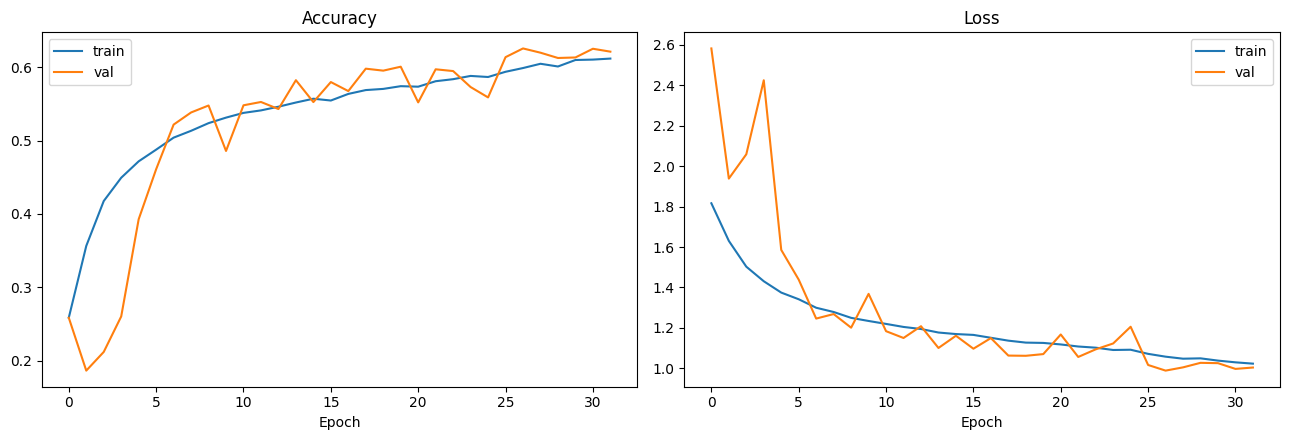

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'training_curves.png'), dpi=150)
plt.show()

## Performance report

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(x_val, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

print(classification_report(y_true, y_pred, target_names=emotion_label, digits=3))

              precision    recall  f1-score   support

       angry      0.509     0.528     0.518       960
     disgust      0.795     0.279     0.413       111
        fear      0.493     0.343     0.404      1018
       happy      0.835     0.866     0.850      1825
     neutral      0.512     0.708     0.594      1216
         sad      0.522     0.457     0.487      1139
    surprise      0.764     0.718     0.740       797

    accuracy                          0.626      7066
   macro avg      0.633     0.557     0.572      7066
weighted avg      0.627     0.626     0.619      7066



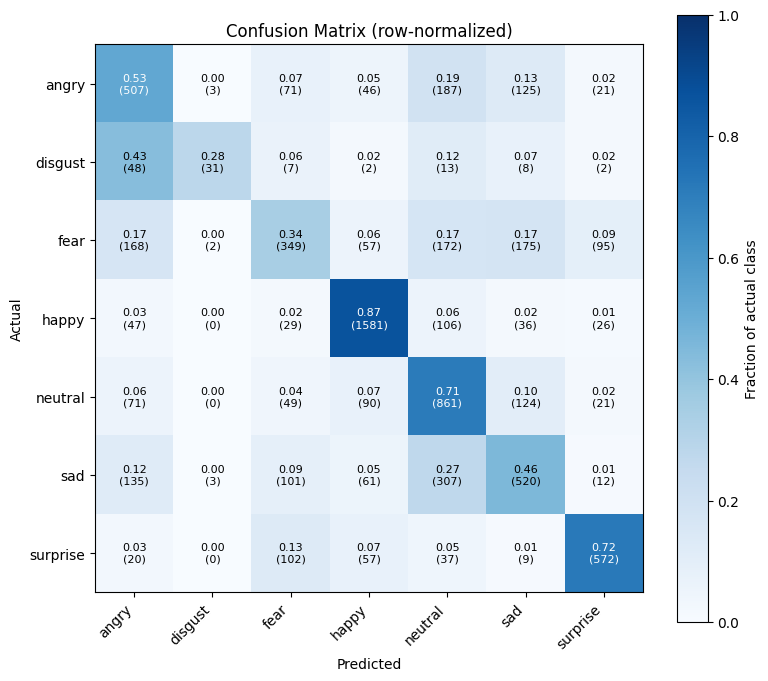

In [35]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(emotion_label)))
ax.set_yticks(range(len(emotion_label)))
ax.set_xticklabels(emotion_label, rotation=45, ha='right')
ax.set_yticklabels(emotion_label)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (row-normalized)')

for i in range(len(emotion_label)):
    for j in range(len(emotion_label)):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i, j]:.2f}\n({cm[i, j]})', ha='center', va='center', color=color, fontsize=8)

fig.colorbar(im, ax=ax, label='Fraction of actual class')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [37]:
import numpy as np
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix
)
y_pred_probs = model.predict(x_val, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

# --- Overall metrics ---
overall_acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')

print("=== Overall ===")
print(f"Accuracy:         {overall_acc:.3f}")
print(f"Macro F1:         {macro_f1:.3f}")
print(f"Weighted F1:      {weighted_f1:.3f}")
print(f"Macro Precision:  {macro_precision:.3f}")
print(f"Macro Recall:     {macro_recall:.3f}")

# --- Random baseline comparison ---
n_classes = len(emotion_label)
random_baseline = 1 / n_classes
improvement = overall_acc / random_baseline
print(f"\n=== Baseline comparison ===")
print(f"Random baseline:  {random_baseline:.3f}")
print(f"Improvement:      {improvement:.2f}x over random")

# --- Per-class breakdown ---
print("\n=== Per-class report ===")
print(classification_report(y_true, y_pred, target_names=emotion_label, digits=3))

# --- Best-performing class---
per_class_f1 = f1_score(y_true, y_pred, average=None)
best_idx = np.argmax(per_class_f1)
print(f"\nStrongest class: {emotion_label[best_idx]} (F1: {per_class_f1[best_idx]:.3f})")

=== Overall ===
Accuracy:         0.626
Macro F1:         0.572
Weighted F1:      0.619
Macro Precision:  0.633
Macro Recall:     0.557

=== Baseline comparison ===
Random baseline:  0.143
Improvement:      4.38x over random

=== Per-class report ===
              precision    recall  f1-score   support

       angry      0.509     0.528     0.518       960
     disgust      0.795     0.279     0.413       111
        fear      0.493     0.343     0.404      1018
       happy      0.835     0.866     0.850      1825
     neutral      0.512     0.708     0.594      1216
         sad      0.522     0.457     0.487      1139
    surprise      0.764     0.718     0.740       797

    accuracy                          0.626      7066
   macro avg      0.633     0.557     0.572      7066
weighted avg      0.627     0.626     0.619      7066


Strongest class: happy (F1: 0.850)
